# Chapter 7

## Load packages

In [1]:
#Packages/dependencies to run Flowkit
import copy
import bokeh
from bokeh.plotting import show
from bokeh.io import export_png
import matplotlib.pyplot as plt

import flowkit as fk

bokeh.io.output_notebook()
%matplotlib inline

_ = plt.ioff()

#Packages/dependencies to run analysis
import pandas as pd
import seaborn as sns
from glob import glob
import numpy as np
import scipy.stats as stats
from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu
from statannotations.Annotator import Annotator

Loading BokehJS ...

## Result section 7.4.2 Strong uORF start codon sequence context represses mORF expression

### Step 1: Gating using flowkit

In [2]:
#Read in the .fcs files
samples_br1 = []
for i in glob("/home/chiga034/projects_limgroup/gab/2025/facs_25/doc/br1/*.fcs"):
    sample = fk.Sample(i, sample_id = i.replace(".fcs", "").replace("/home/chiga034/projects_limgroup/gab/2025/facs_25/doc/br1/Specimen_001_",""))
    samples_br1.append(sample)

samples_br2 = []
for i in glob("/home/chiga034/projects_limgroup/gab/2025/facs_25/doc/br2/*.fcs"):
    sample = fk.Sample(i, sample_id = i.replace(".fcs", "").replace("/home/chiga034/projects_limgroup/gab/2025/facs_25/doc/br2/Specimen_001_",""))
    samples_br2.append(sample)

samples_br3 = []
for i in glob("/home/chiga034/projects_limgroup/gab/2025/facs_25/doc/br3/*.fcs"):
    sample = fk.Sample(i, sample_id = i.replace(".fcs", "").replace("/home/chiga034/projects_limgroup/gab/2025/facs_25/doc/br3/Specimen_001_",""))
    samples_br3.append(sample)
print(samples_br3)

[Sample(v3.1, Mock CTRL, 10 channels, 14667 events), Sample(v3.1, MX3C, 10 channels, 21453 events), Sample(v3.1, Heat Killed, 10 channels, 26244 events), Sample(v3.1, PTB, 10 channels, 17230 events), Sample(v3.1, Unstained (Untransfected), 10 channels, 15073 events), Sample(v3.1, MR112, 10 channels, 18882 events), Sample(v3.1, -ve CTRL Transfected, 10 channels, 16514 events)]


In [3]:
#Create an empty gating strategy and add the gates one by one
g_strat_br1 = fk.GatingStrategy()
g_strat_br2 = fk.GatingStrategy()
g_strat_br3 = fk.GatingStrategy()

fsc_a = fk.Dimension('FSC-A')
ssc_a = fk.Dimension('SSC-A')
fsc_h = fk.Dimension('FSC-H')
ssc_h = fk.Dimension('SSC-H')
ld_nir = fk.Dimension('APC-Cy7-A')
txred = fk.Dimension('PE-Texas Red-A')
dapi = fk.Dimension('DAPI-A')

In [4]:
#x:fsc_a, y:ssc_a
vertices_c1 = [(40000, 15000),(60000, 30000),(75000, 65000),(30000, 65000),(20000,30000)]
c1 = fk.gates.PolygonGate('c1', dimensions=[fsc_a, ssc_a], vertices=vertices_c1)
g_strat_br1.add_gate(c1, gate_path=('root',))

#single cell, x:fsc_a, y:fsc_h
vertices_sc1 = [(30000, 10000),(70000, 25000),(62000, 27000),(30000, 21000)]
sc1 = fk.gates.PolygonGate('sc1', dimensions=[fsc_a, fsc_h], vertices=vertices_sc1)
g_strat_br1.add_gate(sc1, gate_path=('root','c1'))

#single cell2, x:ssc_a, y:ssc_h
vertices_sc2_1 = [(20000, 10000),(70000, 21000),(70000, 40000),(20000, 12000)]
sc2_1 = fk.gates.PolygonGate('sc2_1', dimensions=[ssc_a, ssc_h], vertices=vertices_sc2_1)
g_strat_br1.add_gate(sc2_1, gate_path=('root','c1','sc1'))

#live_dead, x:ld_nir, y:fsc_h
vertices_ld1 = [(-50, 14000),(50, 14000),(50, 27000),(-50, 27000)]
ld1 = fk.gates.PolygonGate('ld1', dimensions=[ld_nir, fsc_h], vertices=vertices_ld1)
g_strat_br1.add_gate(ld1, gate_path=('root','c1','sc1','sc2_1'))

#pop1,2,3,4
vertices_p1_1 = [(600, 5000),(23000, 55000),(600, 55000)]
vertices_p2_1 = [(600, 3000),(600, 5000),(23000, 55000),(23000,48000)]
vertices_p3_1 = [(600, 3000),(600, 900),(23000, 46000),(23000,48000)]
vertices_p4_1 = [(600, 900),(600, 150),(23000, 150),(23000,46000)]

# #pop1,2,3,4
# vertices_p1_1 = [(1000, 10000),(100000, 80000),(100000, 100000),(1000,100000)]
# vertices_p2_1 = [(1000, 6000),(100000, 35000),(100000, 80000),(1000, 10000)]
# vertices_p3_1 = [(1000, 2500),(100000, 19000),(100000, 35000),(1000, 6000)]
# vertices_p4_1 = [(1000, 1000),(100000, 10000),(100000, 19000),(1000, 2500)]

p1_1 = fk.gates.PolygonGate('p1_1', dimensions=[txred, dapi], vertices=vertices_p1_1)
p2_1 = fk.gates.PolygonGate('p2_1', dimensions=[txred, dapi], vertices=vertices_p2_1)
p3_1 = fk.gates.PolygonGate('p3_1', dimensions=[txred, dapi], vertices=vertices_p3_1)
p4_1 = fk.gates.PolygonGate('p4_1', dimensions=[txred, dapi], vertices=vertices_p4_1)

g_strat_br1.add_gate(p1_1, gate_path=('root','c1','sc1','sc2_1','ld1'))
g_strat_br1.add_gate(p2_1, gate_path=('root','c1','sc1','sc2_1','ld1'))
g_strat_br1.add_gate(p3_1, gate_path=('root','c1','sc1','sc2_1','ld1'))
g_strat_br1.add_gate(p4_1, gate_path=('root','c1','sc1','sc2_1','ld1'))

session_br1 = fk.Session(gating_strategy= g_strat_br1, fcs_samples=samples_br1)
session_br1.analyze_samples(verbose=False)

In [5]:
#x:fsc_a, y:ssc_a
vertices_c2 = [(70000, 60000),(70000, 20000),(40000, 20000),(30000, 40000),(50000,60000)]
c2 = fk.gates.PolygonGate('c2', dimensions=[fsc_a, ssc_a], vertices=vertices_c2)
g_strat_br2.add_gate(c2, gate_path=('root',))
#single cell, x:fsc_a, y:fsc_h
vertices_sc2 = [(30000, 12000),(80000, 25000),(62000, 30000),(30000, 20000)]
sc2 = fk.gates.PolygonGate('sc2', dimensions=[fsc_a, fsc_h], vertices=vertices_sc2)
g_strat_br2.add_gate(sc2, gate_path=('root','c2'))
#single cell2, x:ssc_a, y:ssc_h
vertices_sc2_2 = [(20000, 10000),(60000, 22000),(60000, 39000),(20000, 20000)]
sc2_2 = fk.gates.PolygonGate('sc2_2', dimensions=[ssc_a, ssc_h], vertices=vertices_sc2_2)
g_strat_br2.add_gate(sc2_2, gate_path=('root','c2','sc2'))
#live_dead, x:ld_nir, y:fsc_h
vertices_ld2 = [(-50, 14000),(50, 14000),(50, 27000),(-50, 27000)]
ld2 = fk.gates.PolygonGate('ld2', dimensions=[ld_nir, fsc_h], vertices=vertices_ld2)
g_strat_br2.add_gate(ld2, gate_path=('root','c2','sc2','sc2_2'))

#pop1,2,3,4
vertices_p1_2 = [(800, 5000),(26000, 33500),(800, 33500)]
vertices_p2_2 = [(800, 3500),(800, 5000),(26000, 33500),(34000, 33500)]
vertices_p3_2 = [(800, 3500),(800, 2000),(34000, 33500),(30000,33500)]
vertices_p4_2 = [(800, 2000),(34000, 33500),(55000, 33500),(55000,2000)]

p1_2 = fk.gates.PolygonGate('p1_2', dimensions=[txred, dapi], vertices=vertices_p1_2)
p2_2 = fk.gates.PolygonGate('p2_2', dimensions=[txred, dapi], vertices=vertices_p2_2)
p3_2 = fk.gates.PolygonGate('p3_2', dimensions=[txred, dapi], vertices=vertices_p3_2)
p4_2 = fk.gates.PolygonGate('p4_2', dimensions=[txred, dapi], vertices=vertices_p4_2)

g_strat_br2.add_gate(p1_2, gate_path=('root','c2','sc2','sc2_2','ld2'))
g_strat_br2.add_gate(p2_2, gate_path=('root','c2','sc2','sc2_2','ld2'))
g_strat_br2.add_gate(p3_2, gate_path=('root','c2','sc2','sc2_2','ld2'))
g_strat_br2.add_gate(p4_2, gate_path=('root','c2','sc2','sc2_2','ld2'))

session_br2 = fk.Session(gating_strategy= g_strat_br2, fcs_samples=samples_br2)
session_br2.analyze_samples(verbose=False)

In [6]:
#x:fsc_a, y:ssc_a
vertices_c3 = [(50000, 20000),(70000, 50000),(70000, 65000),(30000, 40000)]
c3 = fk.gates.PolygonGate('c3', dimensions=[fsc_a, ssc_a], vertices=vertices_c3)
g_strat_br3.add_gate(c3, gate_path=('root',))

#single cell, x:fsc_a, y:fsc_h
vertices_sc3 = [(40000, 13000),(70000, 20000),(70000, 30000),(30000, 20000)]
sc3 = fk.gates.PolygonGate('sc3', dimensions=[fsc_a, fsc_h], vertices=vertices_sc3)
g_strat_br3.add_gate(sc3, gate_path=('root','c3'))

#single cell2, x:ssc_a, y:ssc_h
vertices_sc2_3 = [(20000, 10000),(70000, 28000),(60000, 35000),(20000, 15000)]
sc2_3 = fk.gates.PolygonGate('sc2_3', dimensions=[ssc_a, ssc_h], vertices=vertices_sc2_3)
g_strat_br3.add_gate(sc2_3, gate_path=('root','c3','sc3'))

#live_dead, x:ld_nir, y:fsc_h
vertices_ld3 = [(-50, 0),(50, 0),(50, 28000),(-50, 28000)]
ld3 = fk.gates.PolygonGate('ld3', dimensions=[ld_nir, fsc_h], vertices=vertices_ld3)
g_strat_br3.add_gate(ld3, gate_path=('root','c3','sc3','sc2_3'))

#pop1,2,3,4
vertices_p1_3 = [(600, 3000),(600, 25000),(17000, 25000)]
vertices_p2_3 = [(19000, 25000),(600, 1500),(600, 3000),(17000,25000)]
vertices_p3_3 = [(19000, 25000),(600, 1500),(600, 150),(21000,25000)]
vertices_p4_3 = [(600, 150),(21000, 150),(21000, 25000)]

p1_3 = fk.gates.PolygonGate('p1_3', dimensions=[txred, dapi], vertices=vertices_p1_3)
p2_3 = fk.gates.PolygonGate('p2_3', dimensions=[txred, dapi], vertices=vertices_p2_3)
p3_3 = fk.gates.PolygonGate('p3_3', dimensions=[txred, dapi], vertices=vertices_p3_3)
p4_3 = fk.gates.PolygonGate('p4_3', dimensions=[txred, dapi], vertices=vertices_p4_3)

g_strat_br3.add_gate(p1_3, gate_path=('root','c3','sc3','sc2_3','ld3'))
g_strat_br3.add_gate(p2_3, gate_path=('root','c3','sc3','sc2_3','ld3'))
g_strat_br3.add_gate(p3_3, gate_path=('root','c3','sc3','sc2_3','ld3'))
g_strat_br3.add_gate(p4_3, gate_path=('root','c3','sc3','sc2_3','ld3'))

session_br3 = fk.Session(gating_strategy= g_strat_br3, fcs_samples=samples_br3)
session_br3.analyze_samples(verbose=False)

In [7]:
logicle_xform = fk.transforms.LogicleTransform(
    param_t=262144,
    param_w=0.5,
    param_m=4.5,
    param_a=0
)
session_br1.add_transform('logicle', logicle_xform)
session_br1.get_transforms()

session_br2.add_transform('logicle', logicle_xform)
session_br2.get_transforms()

session_br3.add_transform('logicle', logicle_xform)
session_br3.get_transforms()

{'logicle': LogicleTransform(t: 262144, w: 0.5, m: 4.5, a: 0)}

#### Save gating plots for supplementary files

In [ ]:
reps = {
    "1": session_br1,
    "2": session_br2,
    "3": session_br3,
}

c_gate_map = {
    "1": "c1",
    "2": "c2",
    "3": "c3",
}

sc_gate_map = {
    "1": "sc1",
    "2": "sc2",
    "3": "sc3",
}

sc2_gate_map = {
    "1": "sc2_1",
    "2": "sc2_2",
    "3": "sc2_3",
}

def rename_sample(sample_id):
    sample_name_map = {
        "-ve CTRL Transfected": "Negative",
        "Heat Killed": "Heat Killed",
        "MR112": "MR112",
        "MX3C": "MX3C",
        "PTB": "PTB",
        "Mock CTRL": "Mock",
        "Unstained (Untransfected)":"Untransfected"
    }

    if sample_id in sample_name_map:
        return sample_name_map[sample_id]

    return sample_id

In [ ]:
# gate c
for rep_name, session in reps.items():
    gate = c_gate_map[rep_name]
    
    for sample_id in session.get_sample_ids():
        nice_name = rename_sample(sample_id)
        p = session.plot_gate(sample_id, gate)
        p.aspect_ratio = 1.0
        p.title.text = nice_name

        export_png(p,filename=f"facs25/facs25_plots/gating/c_{rep_name}_{nice_name}.png")

# gate sc
for rep_name, session in reps.items():
    gate = sc_gate_map[rep_name]
    
    for sample_id in session.get_sample_ids():
        nice_name = rename_sample(sample_id)
        p = session.plot_gate(sample_id, gate, x_min=0, x_max=80000, y_min=5000, y_max=35000)
        p.aspect_ratio = 1.0
        p.title.text = nice_name

        export_png(p,filename=f"facs25/facs25_plots/gating/sc_{rep_name}_{nice_name}.png")

# gate sc2
for rep_name, session in reps.items():
    gate = sc2_gate_map[rep_name]
    
    for sample_id in session.get_sample_ids():
        nice_name = rename_sample(sample_id)
        p = session.plot_gate(sample_id, gate, x_min=0, x_max=80000, y_min=0, y_max=40000)
        p.aspect_ratio = 1.0
        p.title.text = nice_name
        
        export_png(p,filename=f"facs25/facs25_plots/gating/sc2_{rep_name}_{nice_name}.png")

In [12]:
# Plot with transformed data
x_label = 'APC-Cy7-A'
y_label = 'FSC-H'

x_dim = fk.Dimension(x_label, transformation_ref='logicle')
y_dim = fk.Dimension(y_label)

sc2_gate_map = {
    "1": "sc2_1",
    "2": "sc2_2",
    "3": "sc2_3",
}

for rep_name, session in reps.items():
    gate = sc2_gate_map[rep_name]
    
    for sample_id in session.get_sample_ids():
        nice_name = rename_sample(sample_id)
        p = session.plot_scatter(sample_id, x_dim, y_dim, gate_name=gate)
        p.aspect_ratio = 1.0
        p.title.text = nice_name

        export_png(p,filename=f"facs25/facs25_plots/gating/ld_{rep_name}_{nice_name}.png")

# Plot with transformed data
x_label = 'PE-Texas Red-A'
y_label = 'DAPI-A'

x_dim = fk.Dimension(x_label, transformation_ref='logicle')
y_dim = fk.Dimension(y_label, transformation_ref='logicle')

for rep_name, session in reps.items():
    gate = sc2_gate_map[rep_name]
    
    for sample_id in session.get_sample_ids():
        nice_name = rename_sample(sample_id)
        p = session.plot_scatter(sample_id, x_dim, y_dim, gate_name=gate, x_min=-0.05, x_max=0.9, y_min=-0.05, y_max=0.9)
        p.aspect_ratio = 1.0
        p.title.text = nice_name

        export_png(p,filename=f"facs25/facs25_plots/gating/final_{rep_name}_{nice_name}.png")

### Step 2: Extract gated events

In [13]:
#REP1

sample_list_br1 = session_br1.get_sample_ids()

gates = ['c1', 'sc1', 'sc2_1', 'ld1']
pop = ['p1_1','p2_1','p3_1','p4_1']

gate_data = {g: [] for g in gates}
pop_data = {p: [] for p in pop}

for i in sample_list_br1:
    for g, p in zip(gates, pop):
        
        ge = session_br1.get_gate_events(sample_id=i, gate_name=g)
        ge['sample'] = i
        gate_data[g].append(ge)
        pe = session_br1.get_gate_events(sample_id=i, gate_name=p)
        pe['sample'] = i
        pop_data[p].append(pe)
        
for g in gates:
        globals()[f'br1_{g}'] = pd.concat(gate_data[g])

for idx, p in enumerate(pop, start=1):
    globals()[f'br1_{p}'] = pd.concat(pop_data[p])
    globals()[f'br1_{p}'].insert(0,'pop',idx)

#REP2

sample_list_br2 = session_br2.get_sample_ids()

gates = ['c2', 'sc2', 'sc2_2', 'ld2']
pop = ['p1_2','p2_2','p3_2','p4_2']

gate_data = {g: [] for g in gates}
pop_data = {p: [] for p in pop}

for i in sample_list_br2:
    for g, p in zip(gates, pop):
        
        ge = session_br2.get_gate_events(sample_id=i, gate_name=g)
        ge['sample'] = i
        gate_data[g].append(ge)
        pe = session_br2.get_gate_events(sample_id=i, gate_name=p)
        pe['sample'] = i
        pop_data[p].append(pe)
        
for g in gates:
        globals()[f'br2_{g}'] = pd.concat(gate_data[g])

for idx, p in enumerate(pop, start=1):
    globals()[f'br2_{p}'] = pd.concat(pop_data[p])
    globals()[f'br2_{p}'].insert(0,'pop',idx)

#REP3

sample_list_br3 = session_br3.get_sample_ids()

gates = ['c3', 'sc3', 'sc2_3', 'ld3']
pop = ['p1_3','p2_3','p3_3','p4_3']

gate_data = {g: [] for g in gates}
pop_data = {p: [] for p in pop}

for i in sample_list_br3:
    for g, p in zip(gates, pop):
        
        ge = session_br3.get_gate_events(sample_id=i, gate_name=g)
        ge['sample'] = i
        gate_data[g].append(ge)
        pe = session_br3.get_gate_events(sample_id=i, gate_name=p)
        pe['sample'] = i
        pop_data[p].append(pe)
        
for g in gates:
        globals()[f'br3_{g}'] = pd.concat(gate_data[g])

for idx, p in enumerate(pop, start=1):
    globals()[f'br3_{p}'] = pd.concat(pop_data[p])
    globals()[f'br3_{p}'].insert(0,'pop',idx)

In [14]:
#Double positive cells
df_dp1 = pd.concat([br1_p1_1,br1_p2_1,br1_p3_1,br1_p4_1])
df_dp2 = pd.concat([br2_p1_2,br2_p2_2,br2_p3_2,br2_p4_2])
df_dp3 = pd.concat([br3_p1_3,br3_p2_3,br3_p3_3,br3_p4_3])

df_dp1.insert(0,'rep',1)
df_dp2.insert(0,'rep',2)
df_dp3.insert(0,'rep',3)

df_dp = pd.concat([df_dp1,df_dp2,df_dp3])

#Resolve double headers
df_dp.columns = df_dp.columns.get_level_values(0)
df_dp_1 = df_dp[(df_dp['sample']=='-ve CTRL Transfected') | (df_dp['sample']=='Heat Killed') | (df_dp['sample']=='MX3C') | (df_dp['sample']=='Unstained (Untransfected)')]
df_dp_2 = df_dp[(df_dp['sample']=='MR112') | (df_dp['sample']=='Mock CTRL') | (df_dp['sample']=='PTB')]

mask_dups_1 = df_dp_1.columns.duplicated(keep="first")
mask_dups_2 = df_dp_2.columns.duplicated(keep="last")

df_dp_1 = df_dp_1.loc[:, ~mask_dups_1].copy()
df_dp_1 = df_dp_1.rename(columns={'DAPI-A': 'dapi','PE-Texas Red-A':'txred'})
df_dp_2 = df_dp_2.loc[:, ~mask_dups_2].copy()
df_dp_2 = df_dp_2.rename(columns={'DAPI-A': 'dapi','PE-Texas Red-A':'txred'})

df_dp = pd.concat([df_dp_1, df_dp_2])

In [17]:
#Calculating the ratio of Red to Blue and vice versa
df_dp["RatioRB"] = df_dp["txred"]/df_dp["dapi"]
df_dp["RatioBR"] = df_dp["dapi"]/df_dp["txred"]

# df_dp.to_csv('/home/chiga034/projects_limgroup/gab/2026/chapter5/facs25_compiled.csv', index=False)

In [39]:
#long dataframe 
df_dp_long = pd.melt(df_dp, id_vars=["rep","sample", 'pop', "RatioBR",'RatioRB'], value_vars=["txred","dapi"], var_name="reporter", value_name="fi")

### Step 3: Visualisation

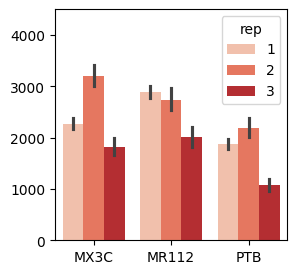

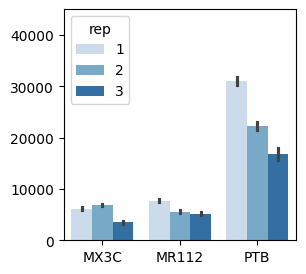

In [69]:
# Figure 7.3(A)
plt.figure(figsize=(3, 3))

# --- txred ---
sns.barplot(
    data=df_dp_long[df_dp_long['reporter']=='txred'],
    x='sample',
    y='fi', 
    hue='rep', 
    palette=sns.color_palette("Reds", n_colors=df_dp_long['rep'].nunique())
)
plt.xlabel('')
plt.ylabel('')
plt.ylim(0,4500)
# plt.savefig('c5_2_fi_comparison_txred.png', dpi=300)
# plt.savefig('c5_2_fi_comparison_txred.pdf')
plt.show()

plt.figure(figsize=(3, 3))

# --- dapi  ---
sns.barplot(
    data=df_dp_long[df_dp_long['reporter']=='dapi'],
    x='sample',
    y='fi', 
    hue='rep', 
    palette=sns.color_palette("Blues", n_colors=df_dp_long['rep'].nunique())
)
plt.xlabel('')
plt.ylabel('')
plt.ylim(0,45000)
# plt.savefig('c5_2_fi_comparison_dapi.png', dpi=300)
# plt.savefig('c5_2_fi_comparison_dapi.pdf')
plt.show()

/tmp/ipykernel_3560123/3463143681.py:7: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(-100,400)


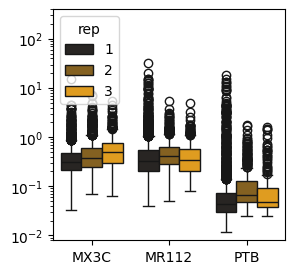

In [63]:
# Figure 7.3(B)
plt.figure(figsize=(3,3))

sns.boxplot(data=df_dp, x="sample", y="RatioRB", hue='rep', palette='dark:orange')
plt.xlabel("")
plt.ylabel("")
plt.yscale('log')
plt.ylim(-100,400)

# plt.savefig('c5_2_ratioRB_comparison.png',dpi=300)
# plt.savefig('c5_2_ratioRB_comparison.pdf')

plt.show()

## Result section 7.4.3 FACS-based separation of reporter populations

/tmp/ipykernel_1060383/2976482371.py:7: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(-10,100)


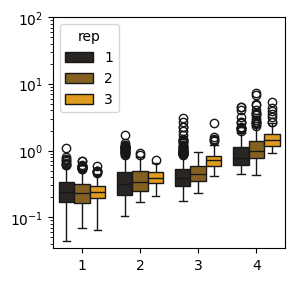

In [126]:
# Figure 7.4(C)
plt.figure(figsize=(3,3))

sns.boxplot(data=df_dp[df_dp['sample']=='MX3C'], x="pop", y="RatioRB", hue='rep', palette='dark:orange')
plt.xlabel("")
plt.ylabel("")
plt.yscale('log')
plt.ylim(-10,100)

# plt.savefig('c5_2_ratioRB_across_pop.png',dpi=300)
# plt.savefig('c5_2_ratioRB_across_pop.pdf')

plt.show()

In [ ]:
df_med = (df_dp.groupby(['sample', 'rep', 'pop'], as_index=False).agg({'RatioRB': 'median','RatioBR':'median'}))

var = [1,2,3,4] 
for i in var:
    g1 = df_med[(df_med['sample']=='MX3C') & (df_med['pop']==i)]['RatioRB']
    g2 = df_med[(df_med['sample']=='MX3C') & (df_med['pop']==4)]['RatioRB']

    fc = g1.median() / g2.median()
    
    t_stat, t_pval = stats.ttest_ind(g1, g2) 
    u_stat, u_pval = stats.mannwhitneyu(g1, g2)
    
    print(f"P{i} vs P4 for RatioRB:")
    print(f"  t-test: stat = {t_stat}, p-value = {t_pval}")
    print(f"  fold change (median): {fc}\n")

## Result section 7.4.4 The optimal uORF start codon sequence context differs from the conventional Kozak sequence

### These are the outputs from DESeq2. The command used to run DESeq2 are in chapter7_deseq2.R

In [18]:
#pop4 vs pop1
ds14 = pd.read_csv('/home/chiga034/projects_limgroup/gab/2025/mutagenesis_pool/mx3c_deseq2/res14.csv')
ds14 = ds14.rename(columns={'Unnamed: 0': 'variants'})
ds14['minus_log10_pvalue'] = -np.log10(ds14['pvalue'])
ds14['comparison'] = 'p4_vs_p1'
ds14_sig = ds14[ds14.pvalue<0.1]

#pop4 vs pop2
ds24 = pd.read_csv('/home/chiga034/projects_limgroup/gab/2025/mutagenesis_pool/mx3c_deseq2/res24.csv')
ds24 = ds24.rename(columns={'Unnamed: 0': 'variants'})
ds24['minus_log10_pvalue'] = -np.log10(ds24['pvalue'])
ds24['comparison'] = 'p4_vs_p2'
ds24_sig = ds24[ds24.pvalue<0.1]

#pop4 vs pop3
ds34 = pd.read_csv('/home/chiga034/projects_limgroup/gab/2025/mutagenesis_pool/mx3c_deseq2/res34.csv')
ds34 = ds34.rename(columns={'Unnamed: 0': 'variants'})
ds34['minus_log10_pvalue'] = -np.log10(ds34['pvalue'])
ds34['comparison'] = 'p4_vs_p3'
ds34_sig = ds34[ds34.pvalue<0.1]

In [19]:
ds = pd.concat([ds14,ds24,ds34]).reset_index(drop=True)
ds_sig = ds[ds.pvalue<0.1]

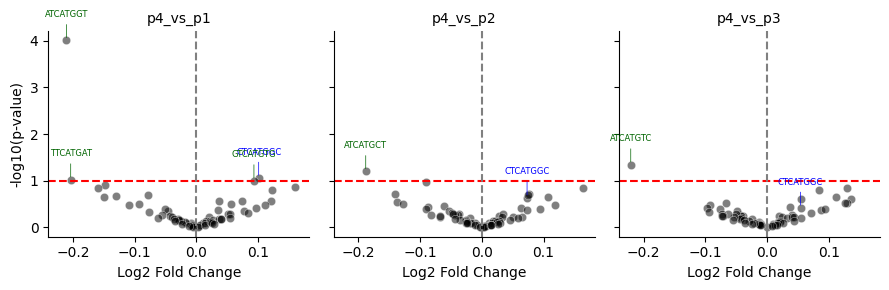

In [20]:
# Figure 7.5(A)
threshold = -np.log10(0.1)

# Create FacetGrid
g = sns.FacetGrid(ds[(ds.comparison!='p4_vs_p5')& (ds.comparison!='p2_vs_p1') & (ds.comparison!='p3_vs_p1') & (ds.comparison!='p3_vs_p2')], col="comparison", 
                  col_wrap=3, height=3, sharex=True, sharey=True)

# Plot the points
g.map_dataframe(
    sns.scatterplot,
    x="log2FoldChange",
    y="minus_log10_pvalue",
    color="black",
    alpha=0.5
)

# Annotate significant and CTCATGGC-containing points
def label_points(data, color, **kwargs):
    ax = plt.gca()
    for _, row in data.iterrows():
        x = row["log2FoldChange"]
        y = row["minus_log10_pvalue"]
        variant = row["variants"]
        
        if "CTCATGGC" in variant:
            ax.annotate(
                variant,
                xy=(x, y), 
                xytext=(x, y + 0.5),  # adjust vertical offset as needed
                fontsize=6,
                color="blue",
                ha="center",
                arrowprops=dict(arrowstyle="-", color="blue", lw=0.5)
            )
        elif y > threshold:
            ax.annotate(
                variant,
                xy=(x, y), 
                xytext=(x, y + 0.5),  # adjust vertical offset
                fontsize=6,
                color="darkgreen",
                ha="center",
                arrowprops=dict(arrowstyle="-", color="darkgreen", lw=0.5)
            )

g.map_dataframe(label_points)

# Add threshold lines
for ax in g.axes.flat:
    ax.axhline(y=threshold, color='red', linestyle='--')
    ax.axvline(x=0, color='gray', linestyle='--')

# Labels and layout
g.set_axis_labels("Log2 Fold Change", "-log10(p-value)")
g.set_titles(col_template="{col_name}")
plt.tight_layout()
#plt.savefig("volcano_plot_facet_for_BMS.png", dpi=300, bbox_inches='tight')
plt.show()

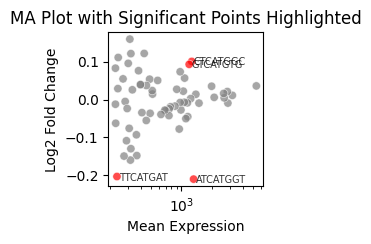

In [21]:
# Figure 7.5(B)
ds['significant'] = (ds['minus_log10_pvalue'] > 1) & (abs(ds['log2FoldChange']) > 0.05)
plt.figure(figsize=(2, 2))
sns.scatterplot(data=ds[ds.comparison=='p4_vs_p1'], x="baseMean", y="log2FoldChange", hue='significant', palette={True: 'red', False: 'grey'}, alpha=0.7)
plt.xscale('log')  # often baseMean is better visualized log scale
plt.xlabel('Mean Expression')
plt.ylabel('Log2 Fold Change')
plt.legend().remove()
plt.title('MA Plot with Significant Points Highlighted')

#If want to label sig points
filtered_ds = ds[(ds['comparison'] == 'p4_vs_p1') & (ds['significant'])]

for _, row in filtered_ds.iterrows():
    plt.text(row['baseMean'] * 1.05,  # Slightly push label to the right
             row['log2FoldChange'] - 0.01,  # Slightly push label up
             row['variants'], fontsize=7, alpha=0.8)
#plt.savefig("ma_plot_p4_vs_p1.png", dpi=300, bbox_inches='tight')
plt.show()